In [1]:
import numpy as np

dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/DEM.npz"
mask_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/Mounds_raster_mask_opened_closed.npy"

data = np.load(dem_path)
dem = data["dataset"].astype(np.float32)
valid = data["validMask"].astype(bool)
mask = np.load(mask_path).astype(np.uint8)

In [6]:
import numpy as np

dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/DEM.npz"

data = np.load(dem_path)
dem = data["dataset"].astype(np.float32)
valid = data["validMask"].astype(bool)

In [7]:
dem[~valid] = -1
to_save = {
    "dem": dem,
    "valid": valid,
}
np.savez_compressed("/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/DEM.npz", **to_save)


In [1]:
import numpy as np

dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/DEM21_opt.npz"

data = np.load(dem_path)
dem = data["dataset"].astype(np.float32)
valid = data["validMask"].astype(bool)

In [2]:
dem.shape

(34995, 22003)

In [2]:
dem_norm = np.zeros_like(dem)
print(np.unique(valid))
dem_norm[dem == 0] = -1
valid[dem_norm == -1] = False

print(dem_norm.shape)
print(valid.shape)
print(np.unique(valid))

[False  True]
(17092, 9791)
(17092, 9791)
[False  True]


In [ ]:
# Global Normalization
dem_norm = np.zeros_like(dem)

dem_norm[valid] = (dem[valid] - dem[valid].min()) / (dem[valid].max() - dem[valid].min())
dem_norm[~valid] = -1

print(dem.shape)
print(dem_norm.shape)
print(dem_norm.min(), dem_norm.max())
print(dem_norm[valid].min(), dem_norm[valid].max())

(34995, 22003)
(34995, 22003)
-1.0 1.0
0.0 1.0


In [3]:
# Per Tile Normalization

## Calculate Norm Constant
h, w = dem.shape
ranges = []

tile_size = 128
percentile = 95

assert dem.shape == valid.shape

for y in range(0, h, tile_size):
    for x in range(0, w, tile_size):
        tile = dem[y:y+tile_size, x:x+tile_size]
        tile_mask = valid[y:y+tile_size, x:x+tile_size].astype(bool)

        # совместная маска валидных значений: и не NaN, и в ValidMask
        is_valid = tile_mask
        if not np.any(is_valid):
            continue

        tile_valid_vals = tile[is_valid]
        r = tile_valid_vals.max() - tile_valid_vals.min()
        ranges.append(r)

ranges = np.array(ranges, dtype=np.float32)
C = np.percentile(ranges, percentile)

print(f"Normalization constant C: {C}")
print(f"Number of tiles: {len(ranges)}")

Normalization constant C: 45.922977447509766
Number of tiles: 10110


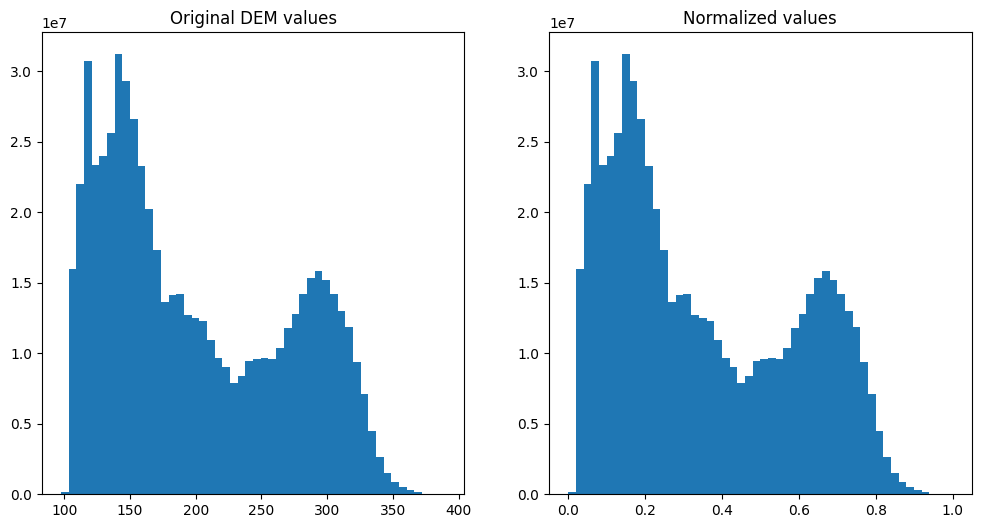

In [21]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.hist(dem[valid].ravel(), bins=50)
plt.title('Original DEM values')
plt.subplot(122)
plt.hist(dem_norm[valid].ravel(), bins=50)
plt.title('Normalized values')
plt.show()

In [4]:
n_samples = dem_norm.shape[0]
train_end = int(n_samples * 0.7)
val_end = train_end + int(n_samples * 0.15)
test_end = train_end + int(n_samples * 0.15)

train_data = dem_norm[:train_end]
val_data = dem_norm[train_end:val_end]
test_data = dem_norm[val_end:]

print(f"Total samples: {n_samples}")
print(f"Training set: {len(train_data)} samples ({len(train_data)/n_samples*100:.1f}%)")
print(f"Validation set: {len(val_data)} samples ({len(val_data)/n_samples*100:.1f}%)")
print(f"Test set: {len(test_data)} samples ({len(test_data)/n_samples*100:.1f}%)")

Total samples: 17092
Training set: 11964 samples (70.0%)
Validation set: 2563 samples (15.0%)
Test set: 2565 samples (15.0%)


In [22]:
to_save={
    "dem": dem_norm,
    "valid": valid
}

#np.savez_compressed("../data/processed/DEM_normalized.npz", **to_save)
np.savez_compressed("../data/processed/DEM21_opt_normalized.npz", **to_save)

In [6]:
from scipy.ndimage import distance_transform_edt

distance = distance_transform_edt(1 - mask) * 1

In [7]:
mask_shadowed = np.where(mask == 1, np.ones_like(distance), np.maximum(0, 1 - (distance / 4)))

In [8]:
mask_shadowed[~valid] = 0

In [9]:
np.unique(mask_shadowed)

array([0.        , 0.09861218, 0.20943058, 0.25      , 0.29289322,
       0.44098301, 0.5       , 0.64644661, 0.75      , 1.        ])

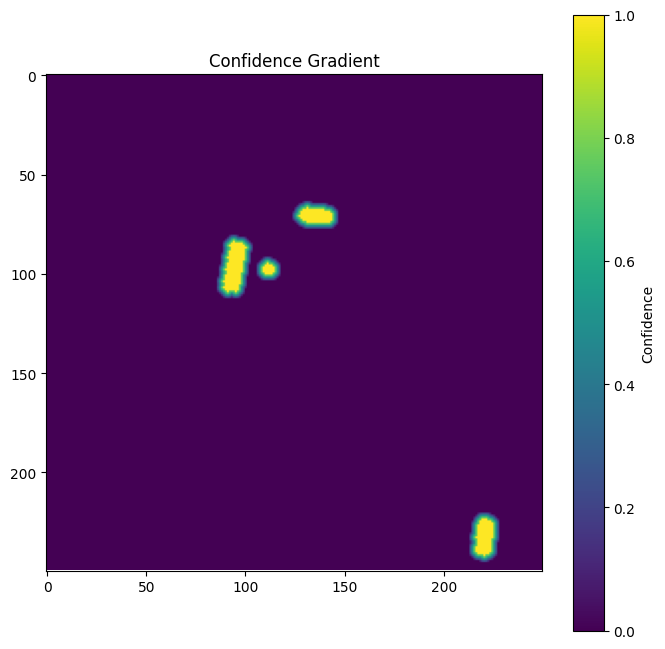

In [10]:
import matplotlib.pyplot as plt
    
patch = mask_shadowed[3000:3250, 3000:3250]
plt.figure(figsize=(8, 8))
plt.imshow(patch, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='Confidence')
plt.title('Confidence Gradient')
plt.show()

In [11]:
np.save(
    "../data/processed/mounds_mask_shadowed.npy", 
    mask_shadowed
)

Train/Val/Test split

In [1]:
dem_normalized_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/DEM_normalized.npz"
mask_shadowed_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/mounds_mask_shadowed.npy"

In [2]:
import numpy as np

dem_normalized_data = np.load(dem_normalized_path)
mask = np.load(mask_shadowed_path)

dem = dem_normalized_data["dem"]
valid = dem_normalized_data["valid"]

In [14]:
print("DEM shape:", dem.shape)
print("DEM min:", dem[valid].min())
print("DEM max:", dem[valid].max())
print("DEM ignore_index:", dem.min())

DEM shape: (17092, 9791)
DEM min: 0.0
DEM max: 1.0
DEM ignore_index: -1.0


In [15]:
h, w = dem.shape
print(f"DEM shape: {dem.shape}")

train_end = int(0.7 * h)
val_end = train_end + int(0.15 * h)

# Split
dem_train = dem[:train_end, :]
dem_val = dem[train_end:val_end, :]
dem_test = dem[val_end:, :]

valid_train = valid[:train_end, :]
valid_val = valid[train_end:val_end, :]
valid_test = valid[val_end:, :]

mask_train = mask[:train_end, :]
mask_val = mask[train_end:val_end, :]
mask_test = mask[val_end:, :]

# Tests
assert dem_train.shape[0] + dem_val.shape[0] + dem_test.shape[0] == h
assert valid_train.shape[0] + valid_val.shape[0] + valid_test.shape[0] == h
assert mask_train.shape[0] + mask_val.shape[0] + mask_test.shape[0] == h
assert dem_train.shape == valid_train.shape == mask_train.shape

DEM shape: (17092, 9791)


In [16]:
import os
save_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/"

dem_train = {"dem": dem_train, "valid": valid_train}
dem_val   = {"dem": dem_val, "valid": valid_val}
dem_test  = {"dem": dem_test, "valid": valid_test}

np.savez_compressed("../data/processed/DEM_normalized_train.npz", **dem_train)
np.savez_compressed("../data/processed/DEM_normalized_val.npz", **dem_val)
np.savez_compressed("../data/processed/DEM_normalized_test.npz", **dem_test)

np.save("../data/processed/mounds_mask_shadowed_train.npy", mask_train)
np.save("../data/processed/mounds_mask_shadowed_val.npy", mask_val)
np.save("../data/processed/mounds_mask_shadowed_test.npy", mask_test)

In [ ]:
import rasterio
from rasterio.windows import Window

# Source file
src_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM.tif"

with rasterio.open(src_path) as src:
    height = src.height
    width = src.width

    train_end = int(0.7 * height)
    val_end = train_end + int(0.15 * height)

    splits = {
        "train": (0, train_end),
        "val": (train_end, val_end),
        "test": (val_end, height)
    }

    for name, (start_row, end_row) in splits.items():
        window = Window(col_off=0, row_off=start_row, width=width, height=end_row - start_row)
        transform = src.window_transform(window)
        
        profile = src.profile
        profile.update({
            "height": end_row - start_row,
            "width": width,
            "transform": transform
        })

        out_path = f"/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM_{name}.tif"
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(src.read(window=window))
        
        print(f"Saved {out_path} — rows {start_row}:{end_row}")

print("All splits completed successfully.")

Saved /home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM_train.tif — rows 0:11964
Saved /home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM_val.tif — rows 11964:14527
Saved /home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM_test.tif — rows 14527:17092
All splits completed successfully.


0.85 Train / 0.15 Val

In [1]:
dem_normalized_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/DEM_normalized.npz"
mask_shadowed_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/mounds_mask_shadowed.npy"

In [2]:
import numpy as np

dem_normalized_data = np.load(dem_normalized_path)
mask = np.load(mask_shadowed_path)

dem = dem_normalized_data["dem"]
valid = dem_normalized_data["valid"]

In [3]:
print("DEM shape:", dem.shape)
print("DEM min:", dem[valid].min())
print("DEM max:", dem[valid].max())
print("DEM ignore_index:", dem.min())

DEM shape: (17092, 9791)
DEM min: 0.0
DEM max: 1.0
DEM ignore_index: -1.0


In [6]:
h, w = dem.shape
print(f"DEM shape: {dem.shape}")

train_end = int(0.85 * h)
val_end = train_end + int(0.15 * h)

print(f"Train end: {train_end}, val end: {val_end}")

# Split
dem_train = dem[:train_end, :]
dem_val = dem[train_end:, :]

valid_train = valid[:train_end, :]
valid_val = valid[train_end:, :]

mask_train = mask[:train_end, :]
mask_val = mask[train_end:, :]

# Tests
assert dem_train.shape[0] + dem_val.shape[0] == h
assert valid_train.shape[0] + valid_val.shape[0] == h
assert mask_train.shape[0] + mask_val.shape[0] == h
assert dem_train.shape == valid_train.shape == mask_train.shape

DEM shape: (17092, 9791)
Train end: 14528, val end: 17091


In [7]:
import os
save_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/"

dem_train = {"dem": dem_train, "valid": valid_train}
dem_val   = {"dem": dem_val, "valid": valid_val}

np.savez_compressed("../data/processed/DEM_normalized_0.85_train.npz", **dem_train)
np.savez_compressed("../data/processed/DEM_normalized_0.85_val.npz", **dem_val)

np.save("../data/processed/mounds_mask_shadowed_0.85_train.npy", mask_train)
np.save("../data/processed/mounds_mask_shadowed_0.85_val.npy", mask_val)

0.80/0.20 Train/Val aka. Cross Validation

In [1]:
dem_normalized_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/DEM_normalized.npz"
mask_shadowed_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/mounds_mask_shadowed.npy"

In [1]:
dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/DEM.npz"

In [2]:
import numpy as np

dem_normalized_data = np.load(dem_normalized_path)
mask = np.load(mask_shadowed_path)

dem = dem_normalized_data["dem"]
valid = dem_normalized_data["valid"]

In [2]:
import numpy as np

dem_data = np.load(dem_path)
dem = dem_data["dataset"].astype(np.float32)
valid = dem_data["validMask"].astype(bool)

dem[~valid] = -1

In [3]:
print("DEM shape:", dem.shape)
print("DEM min:", dem[valid].min())
print("DEM max:", dem[valid].max())
print("DEM ignore_index:", dem.min())

DEM shape: (17092, 9791)
DEM min: 125.835236
DEM max: 376.9557
DEM ignore_index: -1.0


In [4]:
h, w = dem.shape
print(f"h: {h}, w: {w}")
print(f"DEM shape: {dem.shape}")

train_start = int(0.20 * h)
val_end = train_start + int(0.20 * h)
#val_end = h
train_end = h

print(f"Train start: {train_start}")
print(f"Train end: {train_end}")
print(f"Val end: {val_end}")

# Split
dem_train_start = dem[:train_start, :]
dem_train_end = dem[val_end:train_end, :]
dem_train = np.concatenate((dem_train_start, dem_train_end), axis=0)
dem_val = dem[train_start:val_end, :]

valid_train_start = valid[:train_start, :]
valid_train_end = valid[val_end:train_end, :]
valid_train = np.concatenate((valid_train_start, valid_train_end), axis=0)
valid_val = valid[train_start:val_end, :]

#mask_train_start = mask[:train_start, :]
#mask_train_end = mask[val_end:train_end, :]
#mask_train = np.concatenate((mask_train_start, mask_train_end), axis=0)
#mask_val = mask[train_start:val_end, :]

# Tests
assert dem_train.shape[0] + dem_val.shape[0] == h
assert valid_train.shape[0] + valid_val.shape[0] == h
#assert mask_train.shape[0] + mask_val.shape[0] == h
#assert dem_train.shape == valid_train.shape == mask_train.shape

h: 17092, w: 9791
DEM shape: (17092, 9791)
Train start: 3418
Train end: 17092
Val end: 6836


In [ ]:
import os
save_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/"

dem_train = {"dem": dem_train, "valid": valid_train}
dem_val   = {"dem": dem_val, "valid": valid_val}

np.savez_compressed("../data/processed/DEM0.80(4)_train.npz", **dem_train)
np.savez_compressed("../data/processed/DEM0.80(4)_val.npz", **dem_val)

#np.save("../data/processed/mounds_mask0.80(4)_shadowed_train.npy", mask_train)
#np.save("../data/processed/mounds_mask0.80(4)_shadowed_val.npy", mask_val)

Hillshade / Slope

In [2]:
dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/DEM.npz"

In [1]:
dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/DEM21_opt.npz"

In [2]:
import numpy as np

data = np.load(dem_path)
dem = data["dataset"].astype(np.float32)
valid = data["validMask"].astype(bool)

dem = np.where(valid == 1, dem, np.nan)

dem = np.nan_to_num(dem, nan=0.0, posinf=0.0, neginf=0.0)

cellsize = 1.0

dem = np.pad(dem, 1, mode="edge")

In [ ]:
# ========= 3. Extract 3×3 windows ===========
z1 = dem[:-2, :-2]
z2 = dem[:-2, 1:-1]
z3 = dem[:-2, 2:]
z4 = dem[1:-1, :-2]
z5 = dem[1:-1, 1:-1]
z6 = dem[1:-1, 2:]
z7 = dem[2:, :-2]
z8 = dem[2:, 1:-1]
z9 = dem[2:, 2:]

# ========= 4. Compute gradients ===========
dz_dx = ((z3 + 2*z6 + z9) - (z1 + 2*z4 + z7)) / (8.0 * cellsize)
dz_dy = ((z7 + 2*z8 + z9) - (z1 + 2*z2 + z3)) / (8.0 * cellsize)

# ========= 5. SLOPE ===========
slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
slope_deg = slope_rad * 180.0 / np.pi
slope_deg = np.nan_to_num(slope_deg, nan=0.0)

# ========= 6. ASPECT ===========
aspect = np.arctan2(dz_dy, -dz_dx)
aspect = aspect % (2 * np.pi)

# ========= 7. HILLSHADE ===========
azimuth_deg = 315.0
altitude_deg = 45.0

alt = altitude_deg * np.pi / 180.0
az  = ((360.0 - azimuth_deg) + 90.0) % 360.0 * np.pi / 180.0

hillshade = 255 * (
    np.cos(alt) * np.cos(slope_rad) +
    np.sin(alt) * np.sin(slope_rad) * np.cos(az - aspect)
)

hillshade = np.clip(hillshade, 0, 255).astype(np.float32)
hillshade = np.nan_to_num(hillshade, nan=0.0)

slope_norm = slope_deg / 90.0
hillshade_norm = hillshade / 255.0

NameError: name 'slope_rad' is not defined

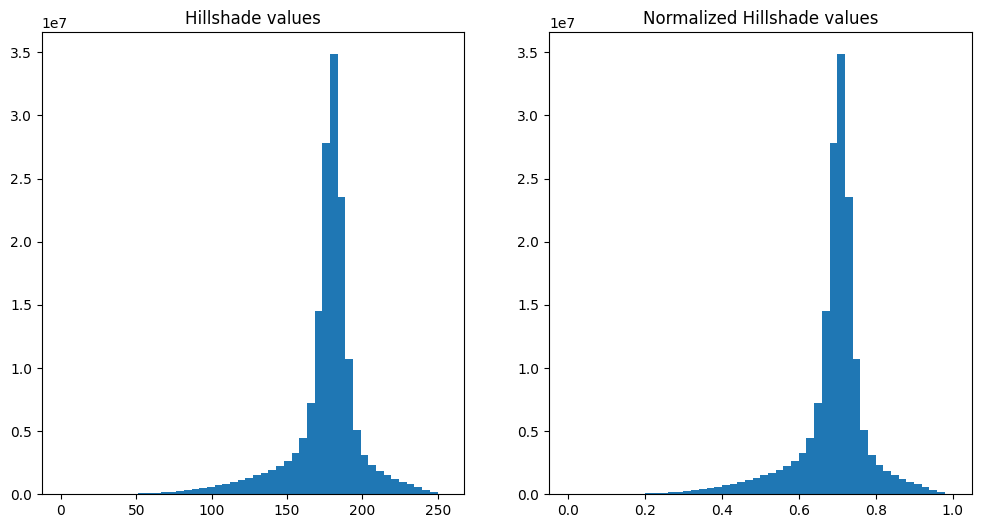

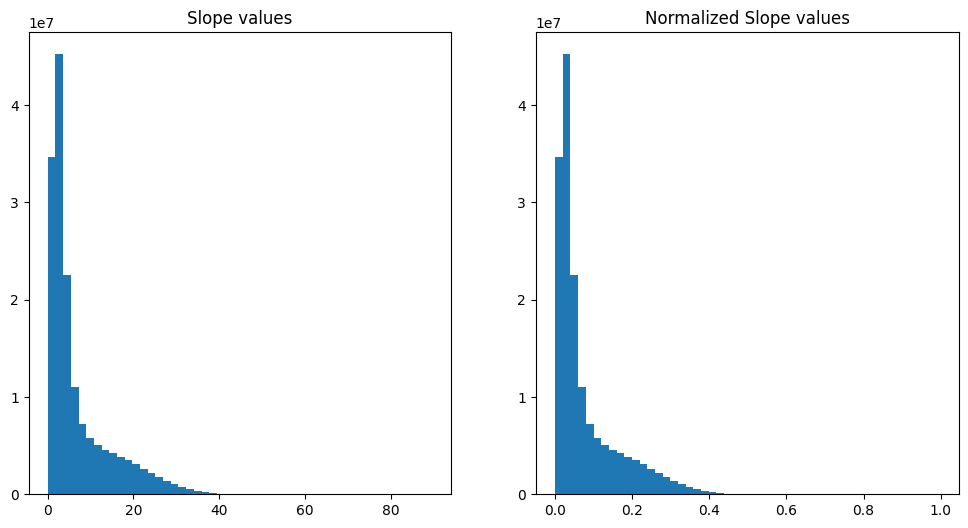

In [5]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.hist(hillshade[valid].ravel(), bins=50)
plt.title('Hillshade values')
plt.subplot(122)
plt.hist(hillshade_norm[valid].ravel(), bins=50)
plt.title('Normalized Hillshade values')
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.title('Slope values')
plt.hist(slope_deg[valid].ravel(), bins=50)
plt.subplot(122)
plt.title('Normalized Slope values')
plt.hist(slope_norm[valid].ravel(), bins=50)
plt.show()

In [5]:
# ========= 9. Save ===========
np.save("../data/processed/DEM_slope_deg.npy", slope_deg)
np.save("../data/processed/DEM_hillshade.npy", hillshade)

In [6]:
np.save("../data/processed/DEM_hillshade_norm.npy", hillshade_norm)
np.save("../data/processed/DEM_slope_norm.npy", slope_norm)

In [5]:
h, w = hillshade_norm.shape
print(f"h: {h}, w: {w}")
print(f"shape: {hillshade_norm.shape}")

train_start = int(0.20 * h)
val_end = train_start + int(0.20 * h)
#val_end = h
train_end = h

print(f"Train start: {train_start}")
print(f"Train end: {train_end}")
print(f"Val end: {val_end}")

# Split
hillshade_train_start = hillshade_norm[:train_start, :]
hillshade_train_end = hillshade_norm[val_end:train_end, :]
hillshade_train = np.concatenate((hillshade_train_start, hillshade_train_end), axis=0)
hillshade_val = hillshade_norm[train_start:val_end, :]

slope_train_start = slope_norm[:train_start, :]
slope_train_end = slope_norm[val_end:train_end, :]
slope_train = np.concatenate((slope_train_start, slope_train_end), axis=0)
slope_val = slope_norm[train_start:val_end, :]

# Tests
assert hillshade_train.shape[0] + hillshade_val.shape[0] == h
assert slope_train.shape[0] + slope_val.shape[0] == h
assert hillshade_train.shape == slope_train.shape
assert hillshade_val.shape == slope_val.shape

h: 17092, w: 9791
shape: (17092, 9791)
Train start: 3418
Train end: 17092
Val end: 6836


In [6]:
np.save("../data/processed/DEM0.80(4)_hillshade_normalized_train.npy", hillshade_train)
np.save("../data/processed/DEM0.80(4)_hillshade_normalized_val.npy", hillshade_val)
np.save("../data/processed/DEM0.80(4)_slope_normalized_train.npy", slope_train)
np.save("../data/processed/DEM0.80(4)_slope_normalized_val.npy", slope_val)
